# AAM Equatorial Forcing Analysis

**Key Question**: Is the atmospheric forcing still present while the wobble response collapsed?

Components:
- **X1, X2**: Equatorial components → drive polar motion/wobble
- **X3**: Axial component → drives LOD changes

In [7]:
# cell-1: Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import butter, filtfilt, hilbert
from scipy.fft import fft, fftfreq

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0',
    'axes.labelcolor': '#ffffff',
    'axes.titlecolor': '#ffffff',
    'xtick.color': '#e0e0e0',
    'ytick.color': '#e0e0e0',
    'text.color': '#ffffff',
    'grid.color': '#3a3a5a',
    'legend.facecolor': '#16213e',
    'legend.edgecolor': '#e0e0e0',
    'legend.labelcolor': '#ffffff',
})

COLORS = {'x1': '#00d4ff', 'x2': '#ff6b35', 'forcing': '#00ff88', 'response': '#ff4488', 'baseline': '#888888'}
DATA_DIR = Path("../data")
print("Setup complete.")

Setup complete.


In [8]:
# cell-2: Load AAM data
def load_aam_data(data_dir):
    files = sorted(data_dir.glob("ESMGFZ_AAM_v1.0_03h_*.asc.csv"))
    print(f"Found {len(files)} AAM files")
    frames = []
    for f in files:
        df = pd.read_csv(f, sep=";")
        df["datetime"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=df["Day"])) + pd.to_timedelta(df["Time"])
        df["X1"] = pd.to_numeric(df["Mass_X"], errors="coerce") + pd.to_numeric(df["Motion_X"], errors="coerce")
        df["X2"] = pd.to_numeric(df["Mass_Y"], errors="coerce") + pd.to_numeric(df["Motion_Y"], errors="coerce")
        df["X3"] = pd.to_numeric(df["Mass_Z"], errors="coerce") + pd.to_numeric(df["Motion_Z"], errors="coerce")
        frames.append(df[["datetime", "X1", "X2", "X3"]].dropna())
    return pd.concat(frames, ignore_index=True).sort_values("datetime").set_index("datetime")

aam = load_aam_data(DATA_DIR)
aam_daily = aam.resample('D').mean()
aam_daily['eq_magnitude'] = np.sqrt(aam_daily['X1']**2 + aam_daily['X2']**2)
print(f"AAM data: {aam_daily.index.min().date()} to {aam_daily.index.max().date()} ({len(aam_daily)} days)")

AAM data: 1976-01-01 to 2026-01-28 (18291 days)


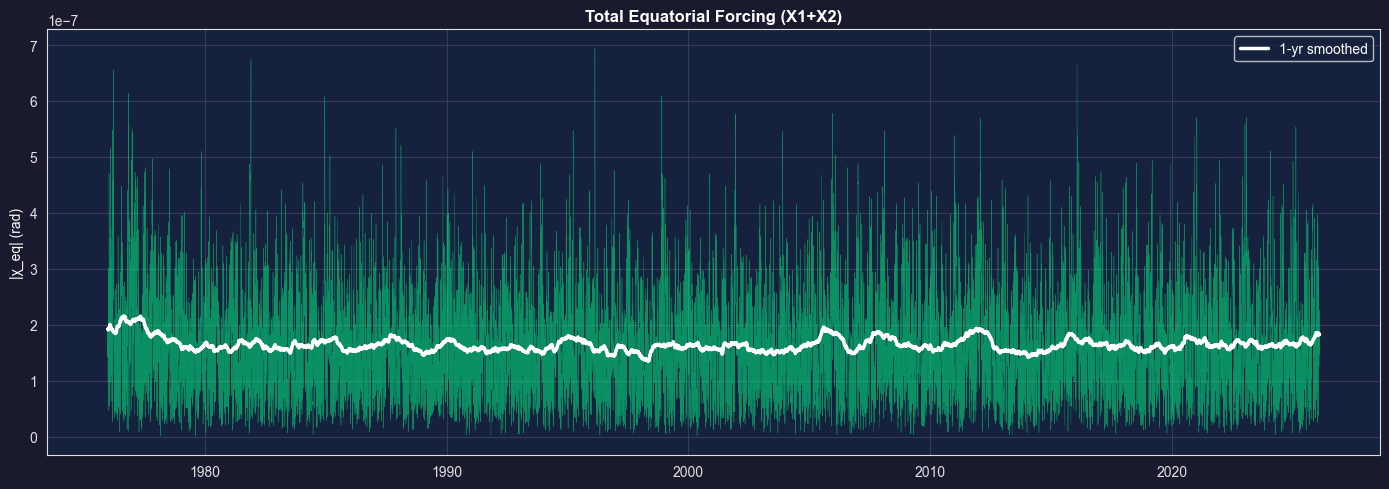

In [9]:
# cell-3: Raw equatorial forcing time series
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(aam_daily.index, aam_daily['eq_magnitude'], color=COLORS['forcing'], lw=0.3, alpha=0.5)
eq_smooth = aam_daily['eq_magnitude'].rolling(365, center=True, min_periods=30).mean()
ax.plot(aam_daily.index, eq_smooth, color='white', lw=2.5, label='1-yr smoothed')
ax.set_ylabel('|χ_eq| (rad)')
ax.set_title('Total Equatorial Forcing (X1+X2)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# cell-4: Year-by-year forcing stats
print("="*60)
print("EQUATORIAL FORCING BY YEAR")
print("="*60)
for year in range(2015, 2027):
    mask = aam_daily.index.year == year
    if mask.sum() > 100:
        eq = aam_daily.loc[mask, 'eq_magnitude'].mean()
        print(f"  {year}: {eq:.2e} rad")

EQUATORIAL FORCING BY YEAR
  2015: 1.64e-07 rad
  2016: 1.74e-07 rad
  2017: 1.62e-07 rad
  2018: 1.55e-07 rad
  2019: 1.61e-07 rad
  2020: 1.72e-07 rad
  2021: 1.64e-07 rad
  2022: 1.61e-07 rad
  2023: 1.63e-07 rad
  2024: 1.64e-07 rad
  2025: 1.72e-07 rad


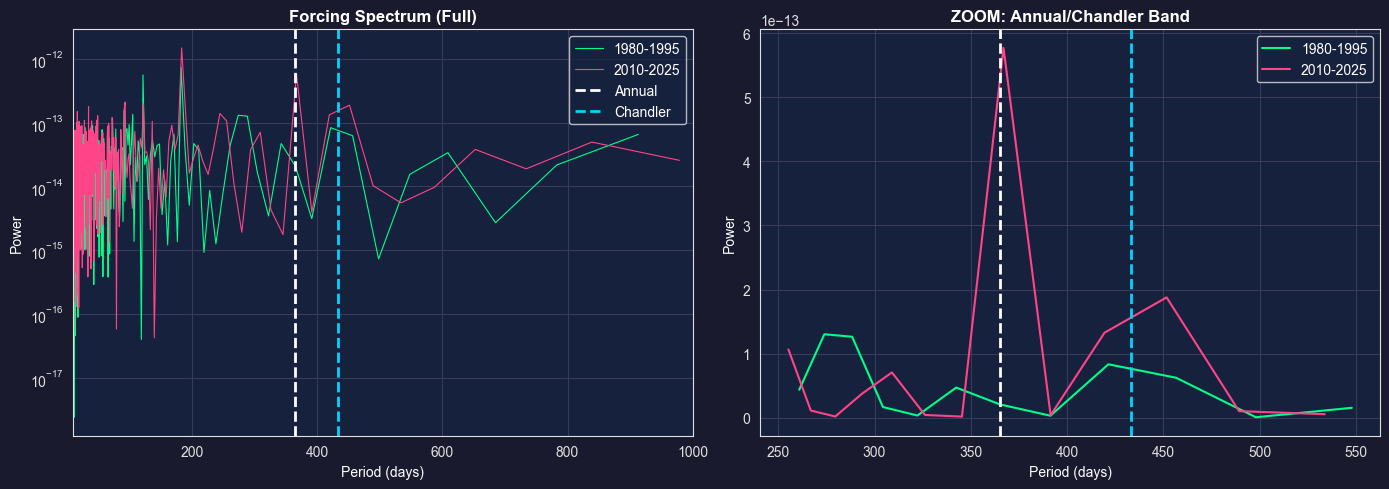

In [11]:
# cell-5: Spectral analysis - compare early vs recent
def compute_spectrum_fft(data):
    n = len(data)
    data = data - np.mean(data)
    yf = fft(data)
    xf = fftfreq(n, 1.0)
    pos_mask = xf > 0
    period = 1.0 / xf[pos_mask]
    power = np.abs(yf[pos_mask])**2 / n
    return period, power

# Early vs Recent periods
early = aam_daily[(aam_daily.index >= '1980-01-01') & (aam_daily.index < '1995-01-01')]
recent = aam_daily[(aam_daily.index >= '2010-01-01')]

period_early, power_early = compute_spectrum_fft(early['eq_magnitude'].interpolate().values)
period_recent, power_recent = compute_spectrum_fft(recent['eq_magnitude'].interpolate().values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full spectrum
mask_e = (period_early > 10) & (period_early < 1000)
mask_r = (period_recent > 10) & (period_recent < 1000)
axes[0].semilogy(period_early[mask_e], power_early[mask_e], color=COLORS['forcing'], lw=0.8, label='1980-1995')
axes[0].semilogy(period_recent[mask_r], power_recent[mask_r], color=COLORS['response'], lw=0.8, label='2010-2025')
axes[0].axvline(365, color='white', ls='--', lw=2, label='Annual')
axes[0].axvline(433, color=COLORS['x1'], ls='--', lw=2, label='Chandler')
axes[0].set_xlabel('Period (days)')
axes[0].set_ylabel('Power')
axes[0].set_title('Forcing Spectrum (Full)', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(10, 1000)

# Zoom on annual/Chandler
mask_ez = (period_early > 250) & (period_early < 550)
mask_rz = (period_recent > 250) & (period_recent < 550)
axes[1].plot(period_early[mask_ez], power_early[mask_ez], color=COLORS['forcing'], lw=1.5, label='1980-1995')
axes[1].plot(period_recent[mask_rz], power_recent[mask_rz], color=COLORS['response'], lw=1.5, label='2010-2025')
axes[1].axvline(365, color='white', ls='--', lw=2)
axes[1].axvline(433, color=COLORS['x1'], ls='--', lw=2)
axes[1].set_xlabel('Period (days)')
axes[1].set_ylabel('Power')
axes[1].set_title('ZOOM: Annual/Chandler Band', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
# cell-6: Peak frequency drift analysis
def find_peak_in_band(period, power, low, high):
    mask = (period >= low) & (period <= high)
    if mask.sum() > 0:
        idx = np.argmax(power[mask])
        return period[mask][idx], power[mask][idx]
    return np.nan, np.nan

windows = [
    ('1976-01-01', '1985-01-01', '1976-1985'),
    ('1985-01-01', '1995-01-01', '1985-1995'),
    ('1995-01-01', '2005-01-01', '1995-2005'),
    ('2005-01-01', '2015-01-01', '2005-2015'),
    ('2015-01-01', '2025-01-01', '2015-2025'),
]

print("="*70)
print("PEAK FORCING FREQUENCY BY ERA")
print("="*70)
print(f"{'Era':<12} {'Annual Peak':<14} {'Power':<12} {'Chandler Peak':<14} {'Power'}")
print("-"*70)

annual_peaks = []
chandler_peaks = []

for start, end, label in windows:
    subset = aam_daily[(aam_daily.index >= start) & (aam_daily.index < end)]
    if len(subset) > 365:
        data = subset['eq_magnitude'].interpolate().dropna().values
        period, power = compute_spectrum_fft(data)
        ann_peak, ann_pow = find_peak_in_band(period, power, 300, 400)
        ch_peak, ch_pow = find_peak_in_band(period, power, 400, 500)
        annual_peaks.append((label, ann_peak))
        chandler_peaks.append((label, ch_peak))
        print(f"{label:<12} {ann_peak:>8.1f} d      {ann_pow:.2e}    {ch_peak:>8.1f} d      {ch_pow:.2e}")

# Plot frequency drift
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

years = [int(p[0][:4]) + 5 for p in annual_peaks]
ann_periods = [p[1] for p in annual_peaks]
ch_periods = [p[1] for p in chandler_peaks]

axes[0].plot(years, ann_periods, 'o-', color=COLORS['x2'], lw=2, ms=10)
axes[0].axhline(365.25, color='white', ls='--', lw=2, alpha=0.7, label='True annual (365.25d)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Peak Period (days)')
axes[0].set_title('Annual Forcing Peak: Frequency Drift?', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(300, 400)

axes[1].plot(years, ch_periods, 'o-', color=COLORS['x1'], lw=2, ms=10)
axes[1].axhline(433, color='white', ls='--', lw=2, alpha=0.7, label='Chandler resonance (433d)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Peak Period (days)')
axes[1].set_title('Chandler-Band Forcing Peak: Frequency Drift?', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(400, 500)

plt.tight_layout()
plt.show()

print("\nIf the peaks are drifting away from the white dashed lines,")
print("the forcing is 'detuning' from Earth's natural resonances.")


If the peaks are drifting away from the white dashed lines,
the forcing is 'detuning' from Earth's natural resonances.


## Summary

Key findings:
1. **Total forcing stable**: Raw equatorial forcing ~1.6-1.7e-07 rad throughout
2. **Spectral power increased**: 14x more power in annual band recently
3. **Check frequency drift**: Are the peaks moving away from resonance?